In [1]:
# 1. Importar librerías necesarias
# ============================================
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt


In [ ]:
# 2. Cargar dataset CIFAR-10
# CIFAR-10 tiene 60,000 imágenes de 32x32 en 10 clases
# Se divide automáticamente en entrenamiento y prueba
# ============================================
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalizamos los valores de píxeles a [0,1]
x_train, x_test = x_train / 255.0, x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
# 3. Definir arquitectura CNN desde cero

cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),  # Definir entrada explícita
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')  # 10 clases en CIFAR-10
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
# 4. Entrenar CNN
# ============================================
history_cnn = cnn_model.fit(x_train, y_train, epochs=10,
                            validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - accuracy: 0.3458 - loss: 1.7653 - val_accuracy: 0.4765 - val_loss: 1.4059
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - accuracy: 0.4733 - loss: 1.4518 - val_accuracy: 0.5569 - val_loss: 1.2180
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.5309 - loss: 1.3185 - val_accuracy: 0.5933 - val_loss: 1.1260
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.5640 - loss: 1.2312 - val_accuracy: 0.6144 - val_loss: 1.0891
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.5900 - loss: 1.1559 - val_accuracy: 0.6308 - val_loss: 1.0338
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.6096 - loss: 1.1043 - val_accuracy: 0.6391 - val_loss: 1.0031
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 47ms/step - accuracy: 0.6297 - loss: 1.0547 - val_accuracy: 0.6562 - val_loss: 0.9653
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6440 -

In [ ]:
# 5. Transfer Learning con MobileNetV2
# Usamos pesos preentrenados en ImageNet
# ============================================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

# Ajustamos tamaño de entrada a 96x96 (MobileNetV2 requiere mínimo 32x32)
x_train_resized = tf.image.resize(x_train, (96,96))
x_test_resized = tf.image.resize(x_test, (96,96))

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96,96,3))
base_model.trainable = False  # congelamos capas

# Añadimos capas finales para clasificación CIFAR-10
tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

tl_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 6. Entrenar modelo con Transfer Learning
# ============================================
history_tl = tl_model.fit(x_train_resized, y_train, epochs=10,
                          validation_data=(x_test_resized, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 417s 262ms/step - accuracy: 0.6847 - loss: 0.9266 - val_accuracy: 0.7794 - val_loss: 0.6380
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 422s 270ms/step - accuracy: 0.7445 - loss: 0.7437 - val_accuracy: 0.7904 - val_loss: 0.6073
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 440s 269ms/step - accuracy: 0.7623 - loss: 0.6965 - val_accuracy: 0.7975 - val_loss: 0.5895
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 440s 267ms/step - accuracy: 0.7702 - loss: 0.6675 - val_accuracy: 0.8029 - val_loss: 0.5711
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 401s 257ms/step - accuracy: 0.7808 - loss: 0.6361 - val_accuracy: 0.7969 - val_loss: 0.5857
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 460s 268ms/step - accuracy: 0.7875 - loss: 0.6169 - val_accuracy: 0.8057 - val_loss: 0.5704
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 425s 272ms/step - accuracy: 0.7952 - loss: 0.5940 - val_accuracy: 0.8102 - val_loss: 0.5628
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 408s 261ms/step - ac

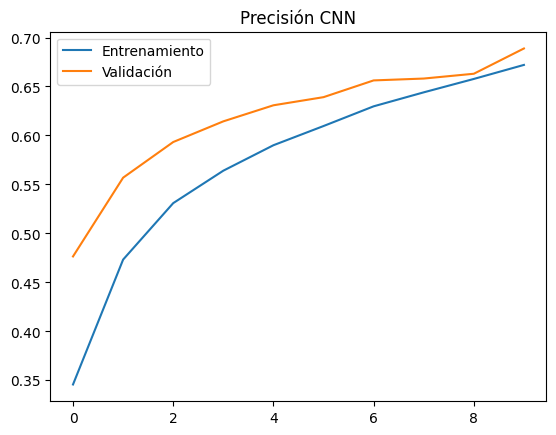

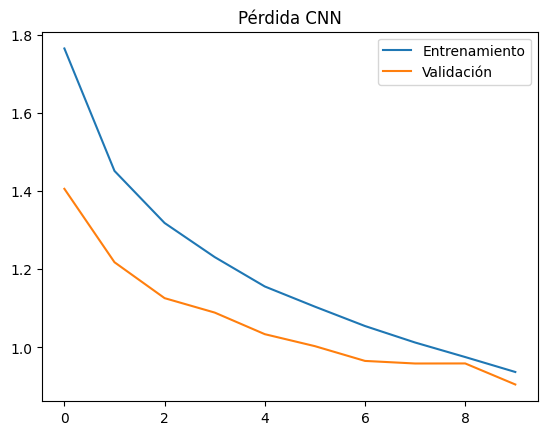

In [ ]:
# 7. Graficar desempeño CNN
# ============================================
plt.plot(history_cnn.history['accuracy'], label='Entrenamiento')
plt.plot(history_cnn.history['val_accuracy'], label='Validación')
plt.title('Precisión CNN')
plt.legend()
plt.show()

plt.plot(history_cnn.history['loss'], label='Entrenamiento')
plt.plot(history_cnn.history['val_loss'], label='Validación')
plt.title('Pérdida CNN')
plt.legend()
plt.show()

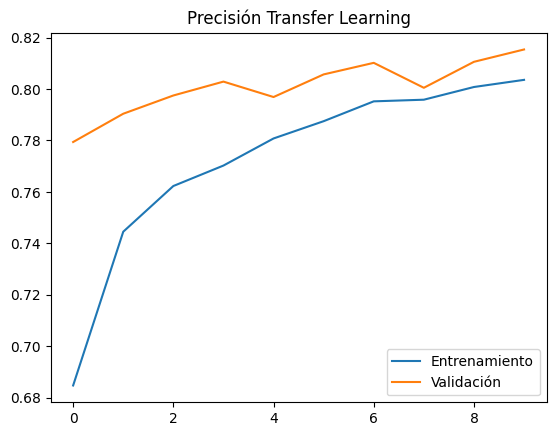

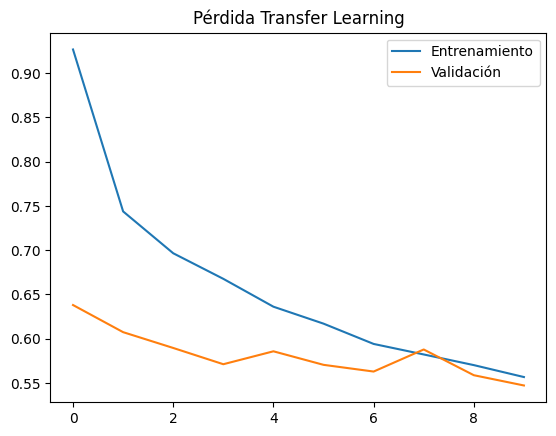

In [ ]:
# 8. Graficar desempeño Transfer Learning
# ============================================
plt.plot(history_tl.history['accuracy'], label='Entrenamiento')
plt.plot(history_tl.history['val_accuracy'], label='Validación')
plt.title('Precisión Transfer Learning')
plt.legend()
plt.show()

plt.plot(history_tl.history['loss'], label='Entrenamiento')
plt.plot(history_tl.history['val_loss'], label='Validación')
plt.title('Pérdida Transfer Learning')
plt.legend()
plt.show()